<a href="https://colab.research.google.com/github/Manojsv20/AI/blob/main/correlation_feature_Exatraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [3]:
data= pd.read_csv("/content/train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


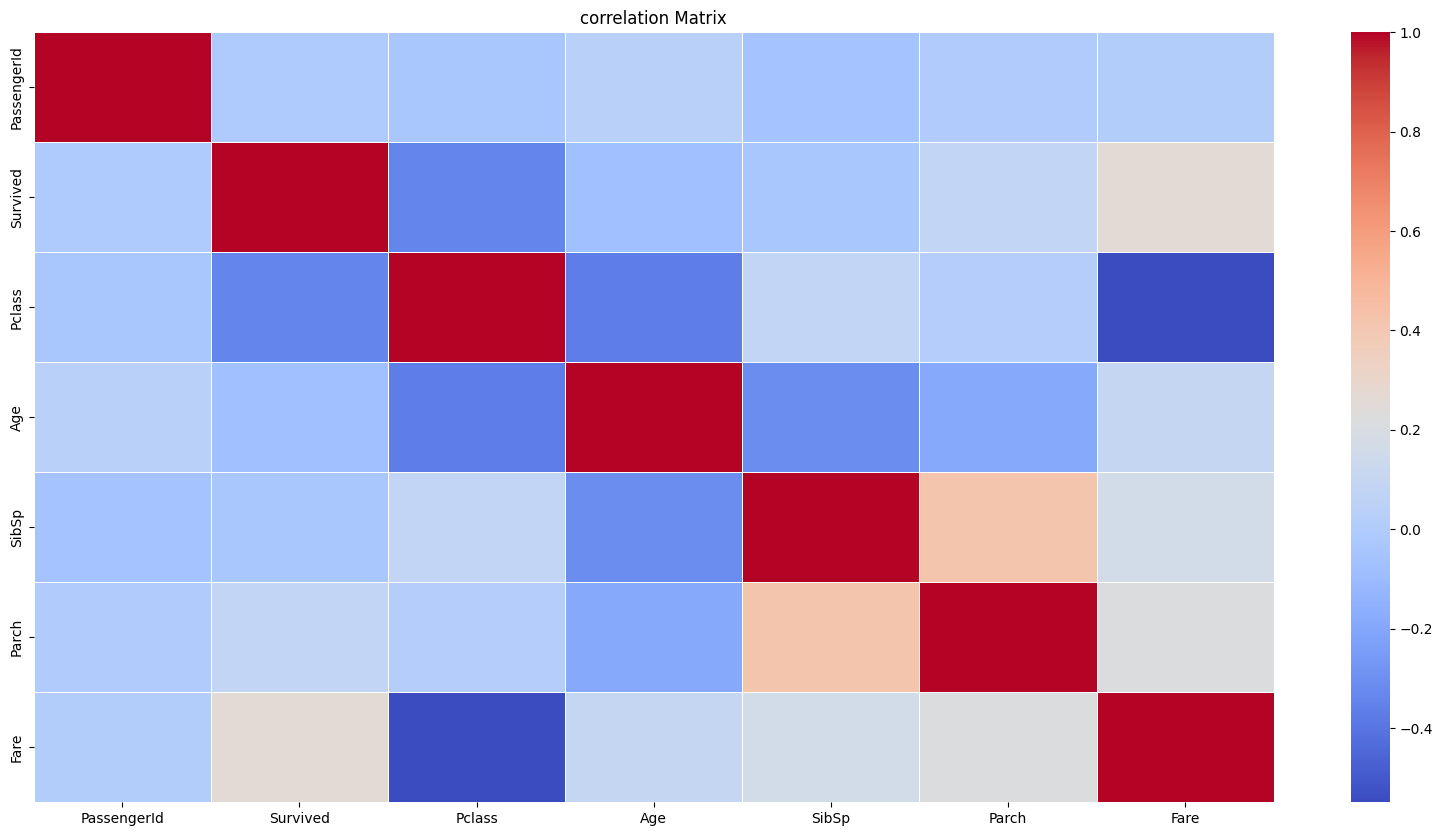

In [5]:


corr=data.corr(numeric_only=True)
plt.figure(figsize=(20,10))

sns.heatmap(corr,annot=False,
    cmap='coolwarm',
    linewidths=0.5)

plt.title("correlation Matrix")

plt.show()

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [9]:
x=data.drop("Survived",axis=1)
y=data["Survived"]


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()

# Identify and drop non-numeric columns from x_train and x_test
non_numeric_cols = x_train.select_dtypes(include=['object', 'category']).columns
x_train_processed = x_train.drop(columns=non_numeric_cols)
x_test_processed = x_test.drop(columns=non_numeric_cols)

model.fit(x_train_processed,y_train)

DecisionTreeClassifier()

In [14]:
y_pred=model.predict(x_test_processed)
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.6480446927374302


In [16]:
corr=data.corr(numeric_only=True)
print(corr)

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


In [21]:
# Calculate correlations of numeric columns with 'Survived'
corr_with_survived = data.corr(numeric_only=True)['Survived']

# Identify columns to drop based on the correlation range (absolute value <= 0.02),
# excluding 'Survived' itself as it's the target variable.
cols_to_drop_based_on_corr = corr_with_survived[(abs(corr_with_survived) <= 0.02)].index.tolist()

# Ensure 'Survived' is not dropped from the feature set if it mistakenly gets into the list
if 'Survived' in cols_to_drop_based_on_corr:
    cols_to_drop_based_on_corr.remove('Survived')

# Drop these columns from the original DataFrame to create the filtered data
data_filtered = data.drop(columns=cols_to_drop_based_on_corr, errors='ignore')

# Define features (x) and target (y) from the filtered data
x = data_filtered.drop("Survived", axis=1)
y = data_filtered["Survived"]
x.shape



(891, 10)

In [18]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()

# Identify and drop non-numeric columns from x_train and x_test
non_numeric_cols = x_train.select_dtypes(include=['object', 'category']).columns
x_train_processed = x_train.drop(columns=non_numeric_cols)
x_test_processed = x_test.drop(columns=non_numeric_cols)

model.fit(x_train_processed,y_train)

DecisionTreeClassifier()

In [19]:
y_pred=model.predict(x_test_processed)
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.6424581005586593


In [22]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42) # Added random_state for reproducibility

# Fit the model to the processed training data
rf_model.fit(x_train_processed, y_train)

# Make predictions on the processed test data
y_pred_rf = rf_model.predict(x_test_processed)

# Calculate and print the accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Classifier Accuracy: {accuracy_rf:.4f}")

Random Forest Classifier Accuracy: 0.7374


In [24]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer

# Initialize the Gradient Boosting Classifier
gbc_model = GradientBoostingClassifier(random_state=42)

# Impute missing values before fitting the model
imputer = SimpleImputer(strategy='mean')

x_train_imputed = pd.DataFrame(imputer.fit_transform(x_train_processed), columns=x_train_processed.columns)
x_test_imputed = pd.DataFrame(imputer.transform(x_test_processed), columns=x_test_processed.columns)

# Fit the model to the imputed training data
gbc_model.fit(x_train_imputed, y_train)

# Make predictions on the imputed test data
y_pred_gbc = gbc_model.predict(x_test_imputed)

# Calculate and print the accuracy
accuracy_gbc = accuracy_score(y_test, y_pred_gbc)
print(f"Gradient Boosting Classifier Accuracy: {accuracy_gbc:.4f}")

Gradient Boosting Classifier Accuracy: 0.7765


In [25]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver often good for smaller datasets

# Fit the model to the imputed training data
log_reg_model.fit(x_train_imputed, y_train)

# Make predictions on the imputed test data
y_pred_lr = log_reg_model.predict(x_test_imputed)

# Calculate and print the accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Classifier Accuracy: {accuracy_lr:.4f}")

Logistic Regression Classifier Accuracy: 0.7263
